In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [10]:
df = pd.read_csv("European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [8]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

KeyError: "['RowNumber'] not found in axis"

In [9]:
df = df.drop(["CustomerId", "Surname"], axis=1)

In [10]:
df.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='str')

In [11]:
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

In [12]:
df.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [14]:
X = df.drop("Exited", axis=1)

# Remove customer name because it is not useful for prediction
if "Surname" in X.columns:
    X = X.drop("Surname", axis=1)

# Convert categorical columns into numbers
X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

y = df["Exited"]

In [14]:
X.shape

(10000, 12)

In [15]:
y.shape

(10000,)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [5]:
rf_model = RandomForestClassifier(random_state=42)

In [6]:
rf_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [21]:
y_pred = rf_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.866


In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1549   58]
 [ 210  183]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [24]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.8544060574680431


In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [26]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [27]:
print(feature_importance)

              Feature  Importance
2                 Age    0.238004
8     EstimatedSalary    0.146685
1         CreditScore    0.142733
4             Balance    0.140057
5       NumOfProducts    0.130347
3              Tenure    0.083283
7      IsActiveMember    0.041734
9   Geography_Germany    0.025325
11        Gender_Male    0.019300
6           HasCrCard    0.018626
10    Geography_Spain    0.013904
0                Year    0.000000


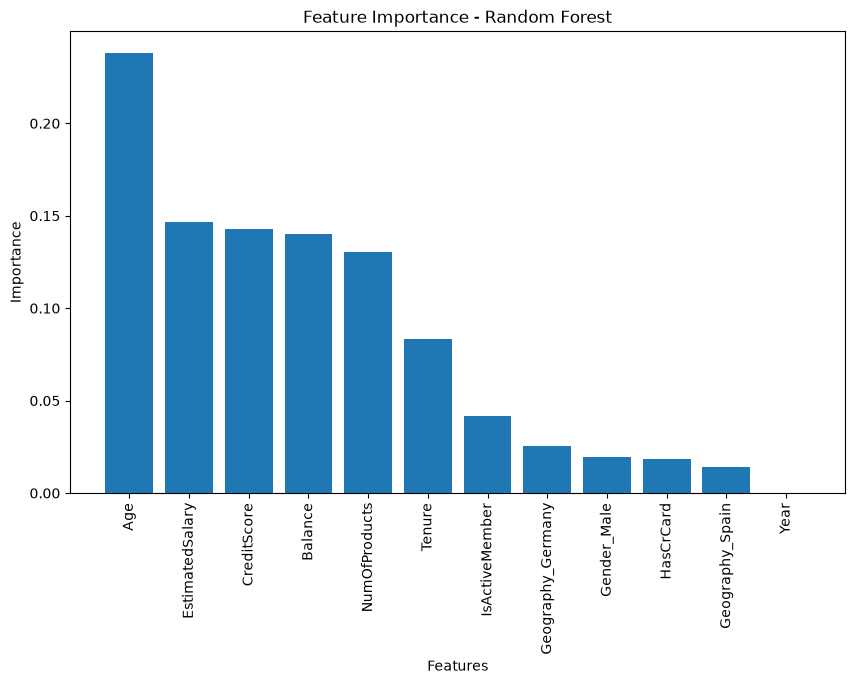

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [29]:
X.columns

Index(['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')

In [30]:
new_customer = [[600, 40, 1, 60000, 2, 1, 1, 50000, 0, 0]]

In [31]:
new_customer = [[
    2024,      # Year
    600,       # CreditScore
    40,        # Age
    5,         # Tenure
    60000,     # Balance
    2,         # NumOfProducts
    1,         # HasCrCard
    1,         # IsActiveMember
    50000,     # EstimatedSalary
    0,         # Geography_Germany
    0,         # Geography_Spain
    1          # Gender_Male
]]

In [32]:
prediction = rf_model.predict(new_customer)

if prediction[0] == 1:
    print("The customer is likely to leave the bank.")
else:
    print("The customer is likely to stay with the bank.")

The customer is likely to leave the bank.


In [33]:
new_customer_scaled = scaler.transform([new_customer])

prediction = rf_model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("The customer is likely to leave the bank.")
else:
    print("The customer is likely to stay with the bank.")

C:\Users\sovag\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: Found array with dim 3, while dim <= 2 is required by StandardScaler.

In [33]:
prediction = rf_model.predict(new_customer)

if prediction[0] == 1:
    print("The customer is likely to leave the bank.")
else:
    print("The customer is likely to stay with the bank.")

The customer is likely to leave the bank.


In [34]:
prediction_probability = rf_model.predict_proba(new_customer)

print("Probability of staying:", prediction_probability[0][0])
print("Probability of leaving:", prediction_probability[0][1])

Probability of staying: 0.33
Probability of leaving: 0.67


In [35]:
churn_rate = df["Exited"].mean() * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 20.37 %


In [37]:
geography_churn = df.groupby("Geography")["Exited"].mean() * 100

print(geography_churn.round(2))

KeyError: 'Geography'

In [36]:
print(df.columns.tolist())

['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [37]:
germany_churn = df[df["Geography_Germany"] == 1]["Exited"].mean() * 100
spain_churn = df[df["Geography_Spain"] == 1]["Exited"].mean() * 100

print("Germany churn rate:", round(germany_churn, 2), "%")
print("Spain churn rate:", round(spain_churn, 2), "%")

Germany churn rate: 32.44 %
Spain churn rate: 16.67 %


In [38]:
age_churn = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "61+"]
)

age_churn_rate = df.groupby(age_churn, observed=True)["Exited"].mean() * 100

print(age_churn_rate.round(2))

Age
18-30     7.50
31-40    12.09
41-50    33.97
51-60    56.21
61+      24.78
Name: Exited, dtype: float64


In [39]:
product_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100

print(product_churn.round(2))

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64


In [40]:
product_counts = df["NumOfProducts"].value_counts().sort_index()

print(product_counts)

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [41]:
activity_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100

print(activity_churn.round(2))

IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


In [42]:
gender_churn = df.groupby("Gender_Male")["Exited"].mean() * 100

print(gender_churn.round(2))

Gender_Male
False    25.07
True     16.46
Name: Exited, dtype: float64


In [43]:
credit_card_churn = df.groupby("HasCrCard")["Exited"].mean() * 100

print(credit_card_churn.round(2))

HasCrCard
0    20.81
1    20.18
Name: Exited, dtype: float64


In [44]:
tenure_churn = df.groupby("Tenure")["Exited"].mean() * 100

print(tenure_churn.round(2))

Tenure
0     23.00
1     22.42
2     19.18
3     21.11
4     20.53
5     20.65
6     20.27
7     17.22
8     19.22
9     21.65
10    20.61
Name: Exited, dtype: float64


In [47]:
balance_group = pd.qcut(
    df["Balance"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

balance_churn = df.groupby(balance_group, observed=True)["Exited"].mean() * 100

print(balance_churn.round(2))

ValueError: Bin edges must be unique: Index([0.0, 0.0, 97198.54000000001, 127644.24, 250898.09], dtype='float64', name='Balance').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [45]:
balance_group = pd.cut(
    df["Balance"],
    bins=[-1, 50000, 100000, 150000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

balance_churn = df.groupby(balance_group, observed=True)["Exited"].mean() * 100

print(balance_churn.round(2))

Balance
Low          14.25
Medium       19.88
High         25.77
Very High    23.12
Name: Exited, dtype: float64


In [46]:
credit_score_group = pd.cut(
    df["CreditScore"],
    bins=[0, 600, 700, 800, 900],
    labels=["Low", "Medium", "High", "Very High"]
)

credit_score_churn = df.groupby(
    credit_score_group, observed=True
)["Exited"].mean() * 100

print(credit_score_churn.round(2))

CreditScore
Low          21.69
Medium       19.72
High         19.91
Very High    19.69
Name: Exited, dtype: float64


In [47]:
salary_group = pd.cut(
    df["EstimatedSalary"],
    bins=[0, 50000, 100000, 150000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

salary_churn = df.groupby(
    salary_group, observed=True
)["Exited"].mean() * 100

print(salary_churn.round(2))

EstimatedSalary
Low          19.93
Medium       19.87
High         20.23
Very High    21.47
Name: Exited, dtype: float64


In [48]:
df["Geography"] = "France"

df.loc[df["Geography_Germany"] == 1, "Geography"] = "Germany"
df.loc[df["Geography_Spain"] == 1, "Geography"] = "Spain"

geography_churn = df.groupby("Geography")["Exited"].mean() * 100

print(geography_churn.round(2))

Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


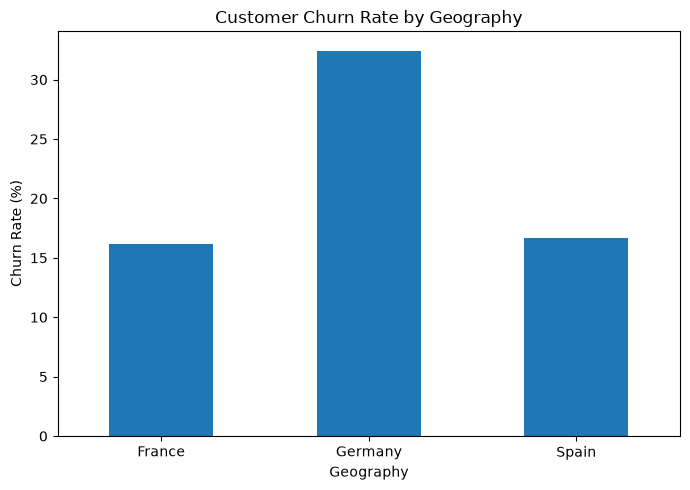

In [49]:
import matplotlib.pyplot as plt

geography_churn = df.groupby("Geography")["Exited"].mean() * 100

plt.figure(figsize=(7, 5))
geography_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_geography.png", dpi=300, bbox_inches="tight")
plt.show()

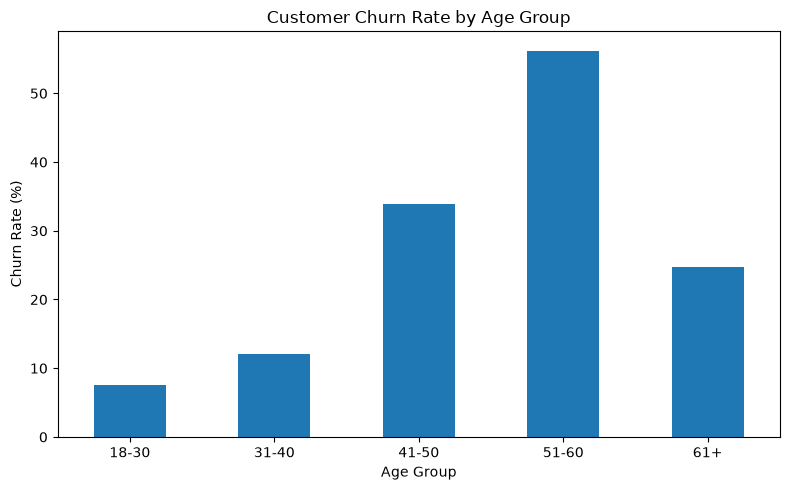

In [50]:
import matplotlib.pyplot as plt

age_churn_rate.plot(kind="bar", figsize=(8, 5))

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

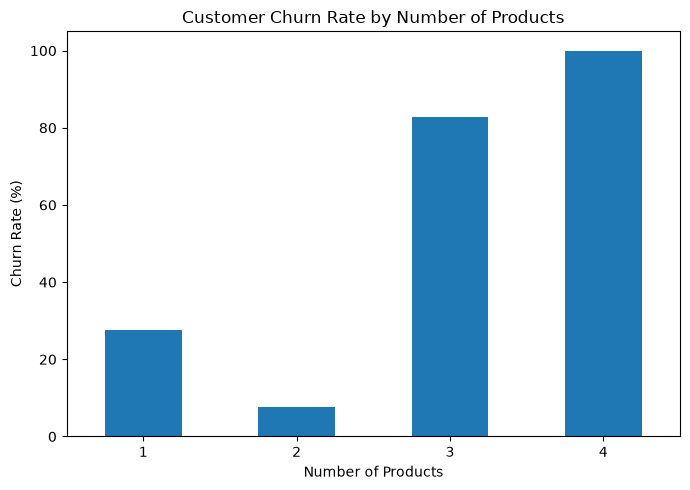

In [51]:
import matplotlib.pyplot as plt

product_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

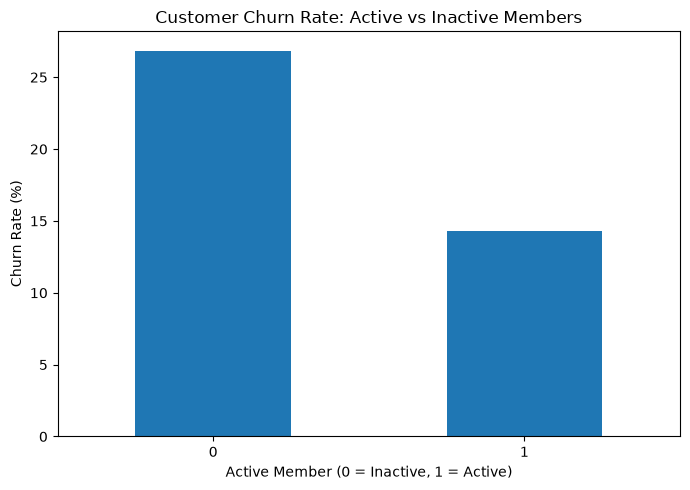

In [52]:
import matplotlib.pyplot as plt

activity_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate: Active vs Inactive Members")
plt.xlabel("Active Member (0 = Inactive, 1 = Active)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

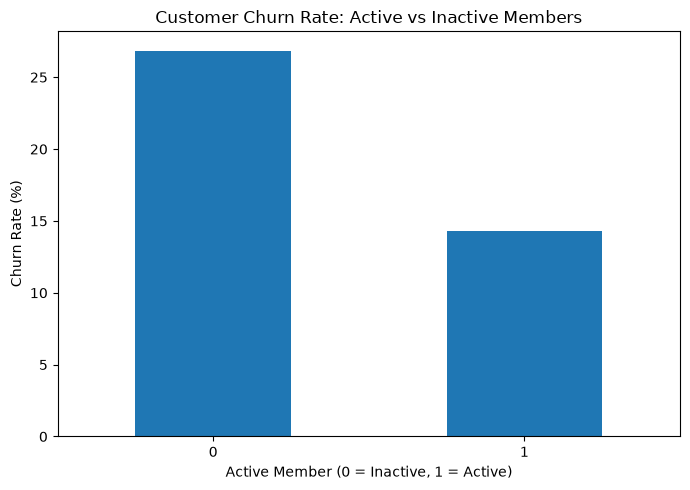

In [53]:
import matplotlib.pyplot as plt

activity_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate: Active vs Inactive Members")
plt.xlabel("Active Member (0 = Inactive, 1 = Active)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

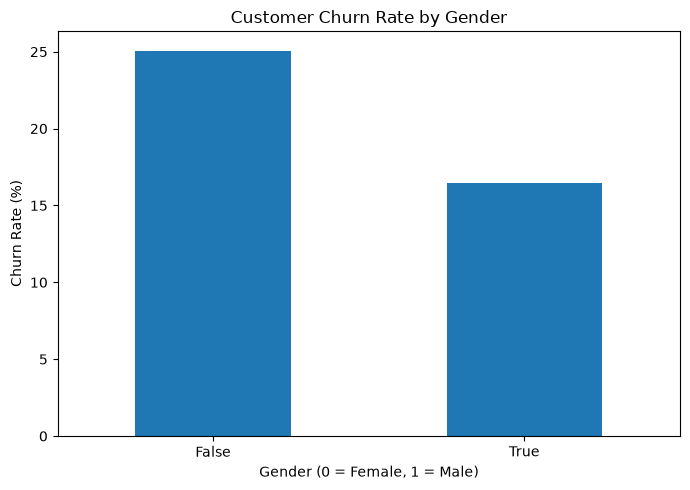

In [54]:
gender_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

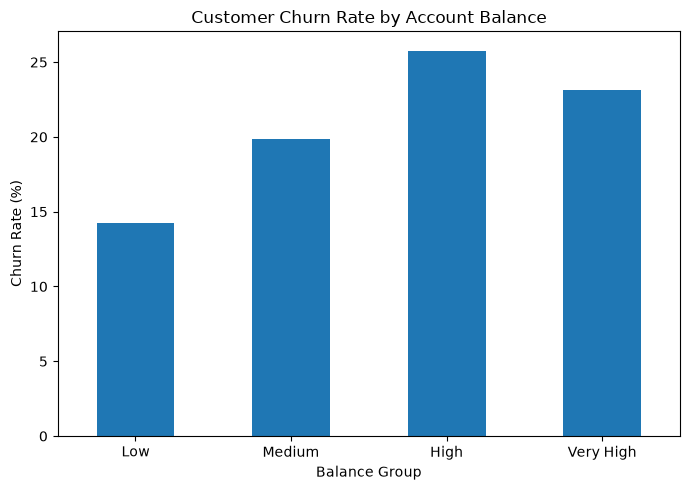

In [55]:
balance_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

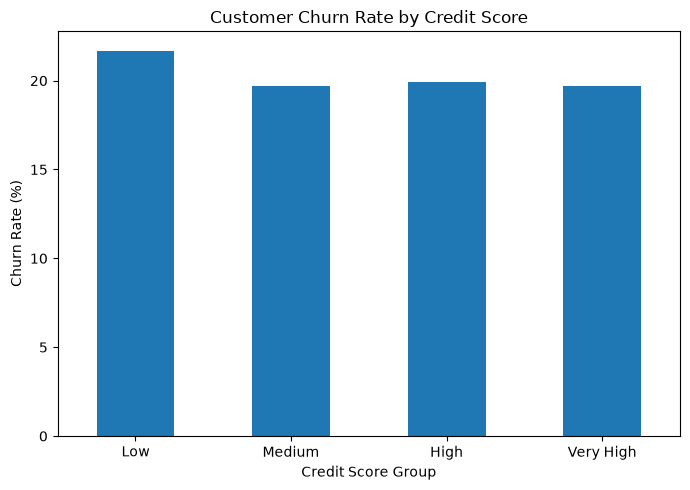

In [56]:
credit_score_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate by Credit Score")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

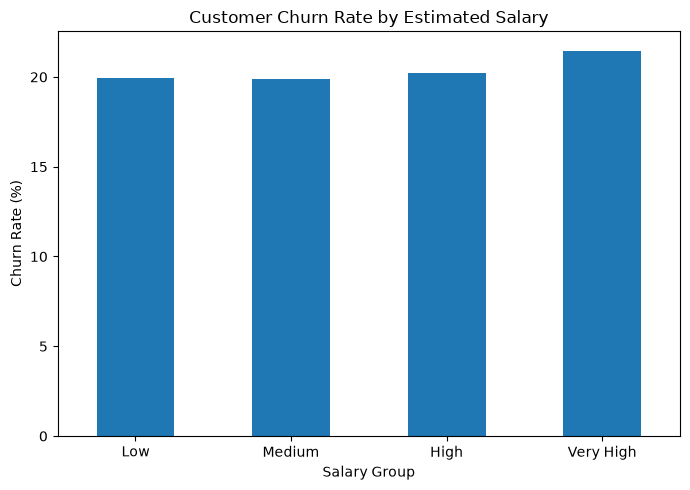

In [57]:
salary_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Customer Churn Rate by Estimated Salary")
plt.xlabel("Salary Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

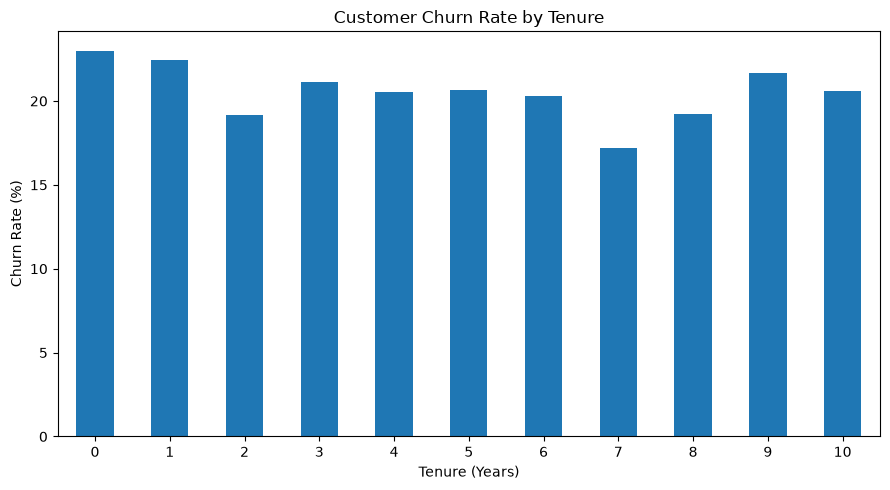

In [58]:
tenure_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

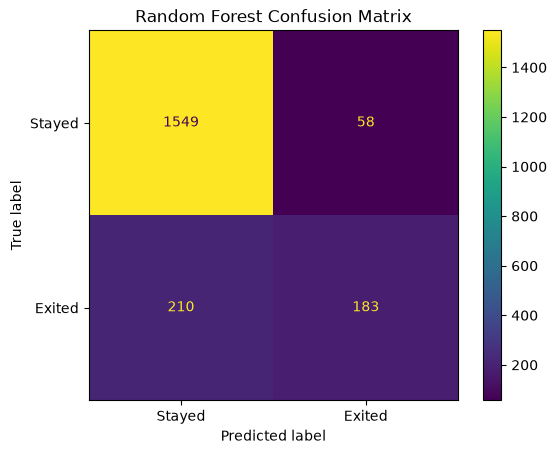

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Exited"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

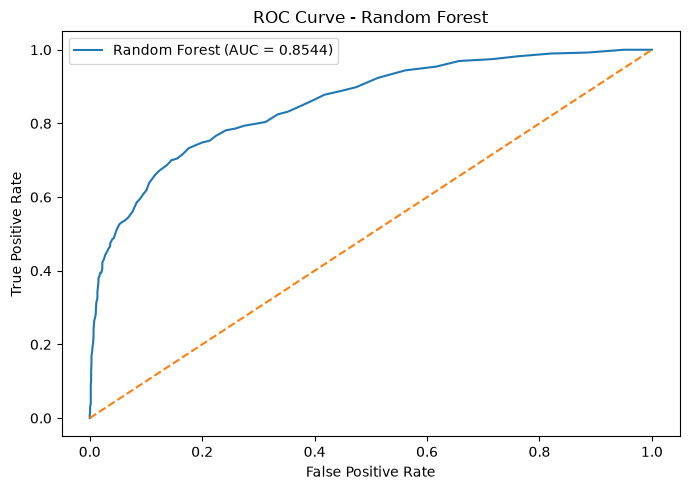

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Age                  0.238004
EstimatedSalary      0.146685
CreditScore          0.142733
Balance              0.140057
NumOfProducts        0.130347
Tenure               0.083283
IsActiveMember       0.041734
Geography_Germany    0.025325
Gender_Male          0.019300
HasCrCard            0.018626
Geography_Spain      0.013904
Year                 0.000000
dtype: float64


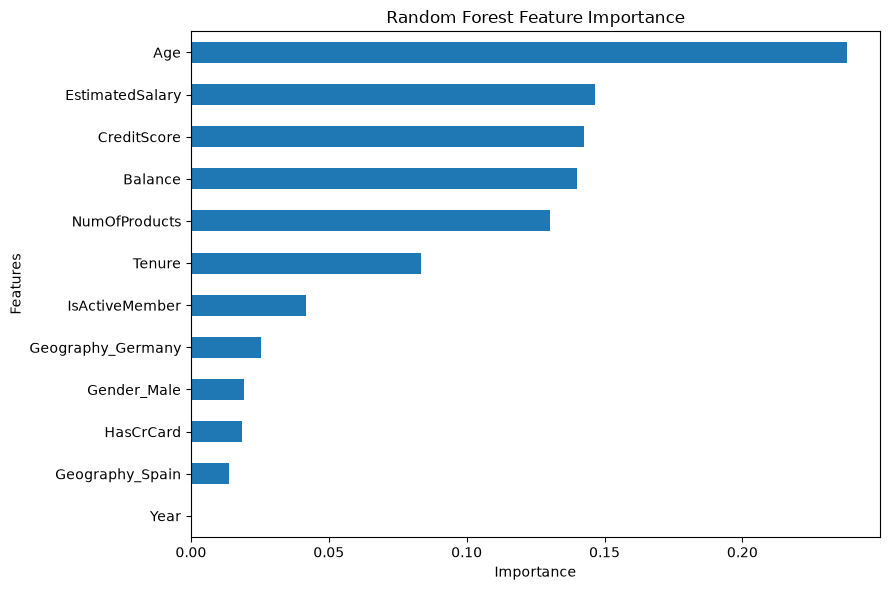

In [62]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [63]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Exited"]
))

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1607
      Exited       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [64]:
print("Business Insight Summary")
print("------------------------")
print("Overall churn rate:", round(df["Exited"].mean() * 100, 2), "%")
print("Highest-risk geography: Germany (32.44%)")
print("Highest-risk age group: 51-60 (56.21%)")
print("Inactive member churn: 26.85%")
print("Active member churn: 14.27%")
print("Random Forest accuracy: 87%")
print("Random Forest ROC-AUC: 0.8544")

Business Insight Summary
------------------------
Overall churn rate: 20.37 %
Highest-risk geography: Germany (32.44%)
Highest-risk age group: 51-60 (56.21%)
Inactive member churn: 26.85%
Active member churn: 14.27%
Random Forest accuracy: 87%
Random Forest ROC-AUC: 0.8544


In [65]:
print("Business Recommendations")
print("-------------------------")
print("1. Focus retention efforts on customers aged 51-60, who show the highest observed churn rate.")
print("2. Prioritize customers in Germany because its observed churn rate is substantially higher than France and Spain.")
print("3. Develop engagement strategies for inactive members, who show a higher churn rate than active members.")
print("4. Monitor customers with three or more products, while interpreting the high churn rates cautiously because these groups are relatively small.")
print("5. Pay attention to high-balance customers because they show higher observed churn than low-balance customers.")
print("6. Use the Random Forest model to identify customers with elevated churn probability and prioritize them for retention campaigns.")
print("7. Improve the model's ability to detect actual churners, since recall for the Exited class is currently 47%.")

Business Recommendations
-------------------------
1. Focus retention efforts on customers aged 51-60, who show the highest observed churn rate.
2. Prioritize customers in Germany because its observed churn rate is substantially higher than France and Spain.
3. Develop engagement strategies for inactive members, who show a higher churn rate than active members.
4. Monitor customers with three or more products, while interpreting the high churn rates cautiously because these groups are relatively small.
5. Pay attention to high-balance customers because they show higher observed churn than low-balance customers.
6. Use the Random Forest model to identify customers with elevated churn probability and prioritize them for retention campaigns.
7. Improve the model's ability to detect actual churners, since recall for the Exited class is currently 47%.


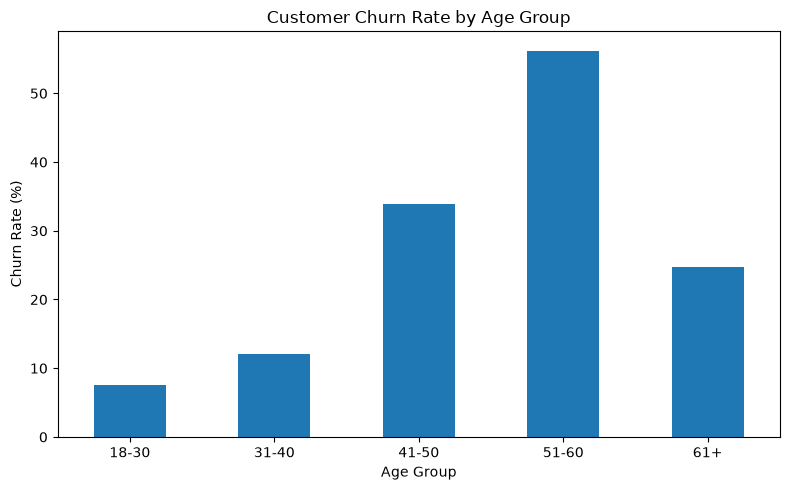

In [66]:
plt.figure(figsize=(8, 5))

age_churn_rate.plot(kind="bar")

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

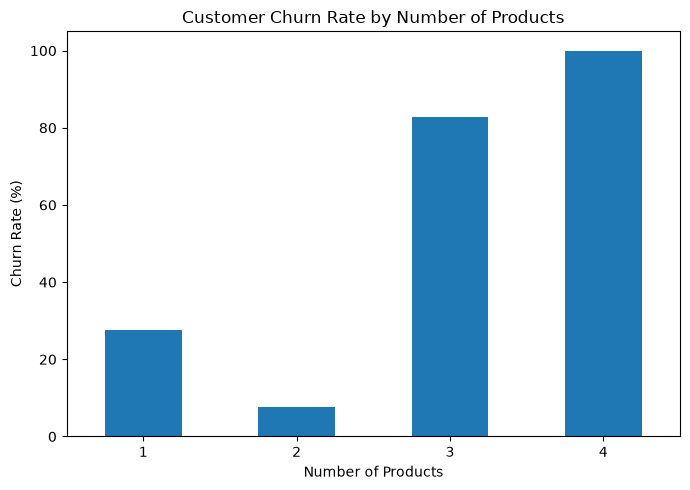

In [67]:
plt.figure(figsize=(7, 5))

product_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_number_of_products.png", dpi=300, bbox_inches="tight")
plt.show()

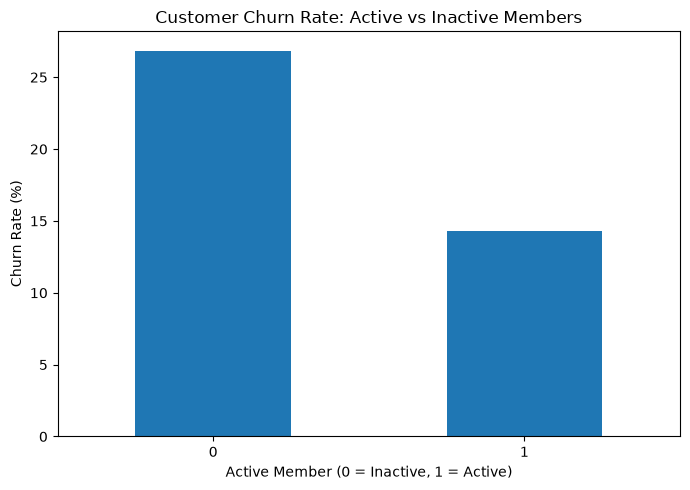

In [68]:
plt.figure(figsize=(7, 5))

activity_churn.plot(kind="bar")

plt.title("Customer Churn Rate: Active vs Inactive Members")
plt.xlabel("Active Member (0 = Inactive, 1 = Active)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_active_vs_inactive.png", dpi=300, bbox_inches="tight")
plt.show()

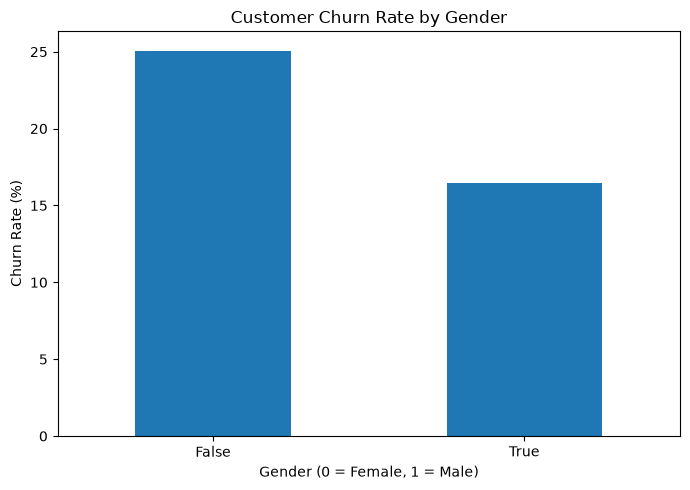

In [69]:
plt.figure(figsize=(7, 5))

gender_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

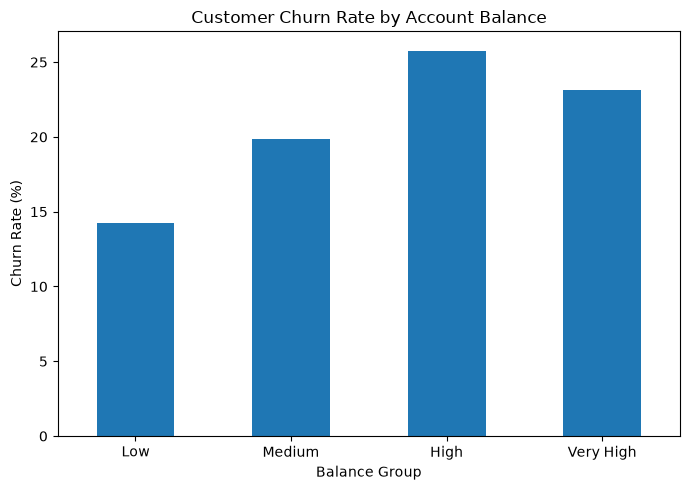

In [70]:
plt.figure(figsize=(7, 5))

balance_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("churn_by_balance.png", dpi=300, bbox_inches="tight")
plt.show()

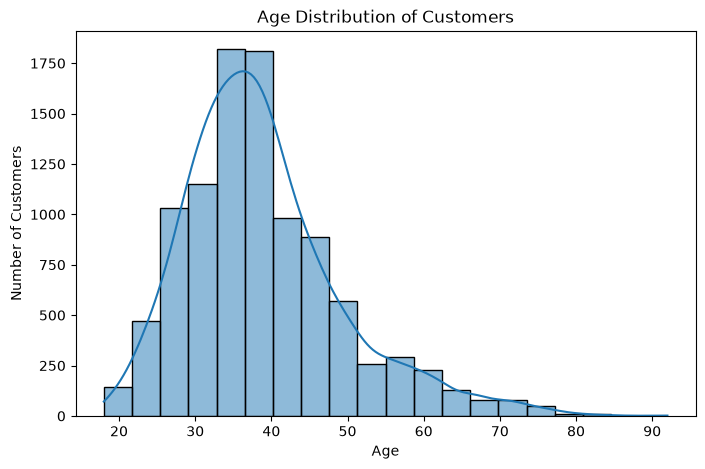

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

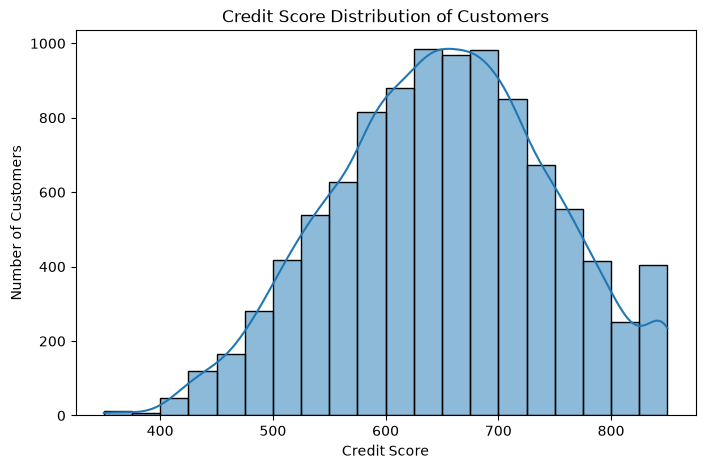

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], bins=20, kde=True)
plt.title('Credit Score Distribution of Customers')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.savefig('credit_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

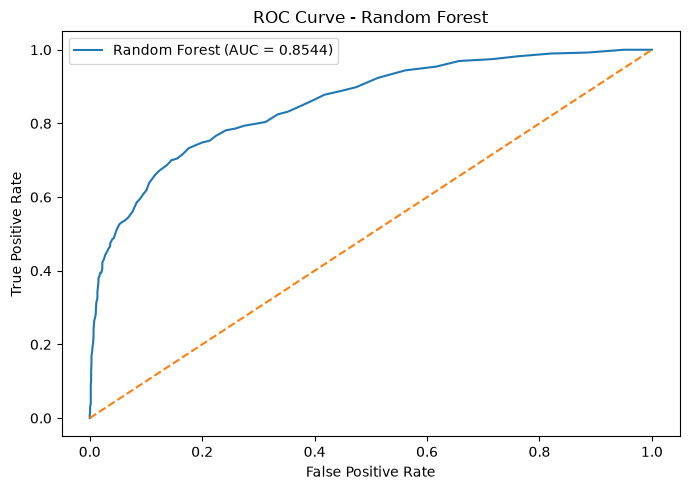

In [73]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()

plt.savefig("random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

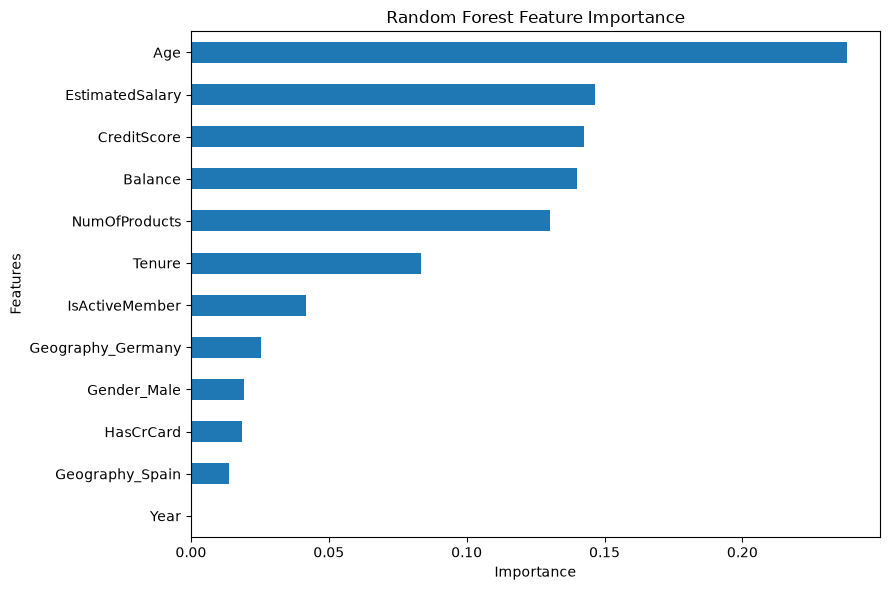

In [79]:
plt.figure(figsize=(9, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()

plt.savefig("random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Exited"]
))

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1607
      Exited       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [1]:
balance_churn = pd.qcut(
    df["Balance"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

balance_churn_rate = df.groupby(balance_churn, observed=True)["Exited"].mean() * 100

plt.figure(figsize=(7, 5))

balance_churn_rate.plot(kind="bar")

plt.title("Customer Churn Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("churn_by_balance.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'pd' is not defined

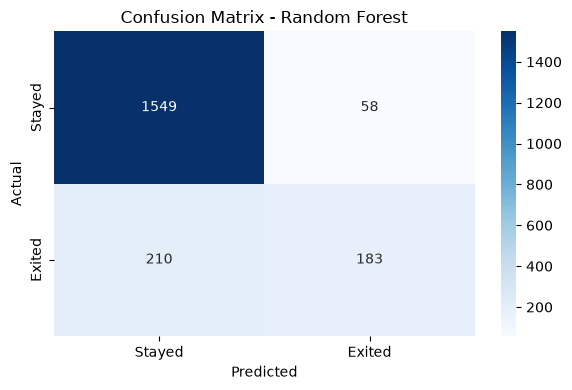

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Exited"],
    yticklabels=["Stayed", "Exited"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

ROC-AUC Score: 0.8544


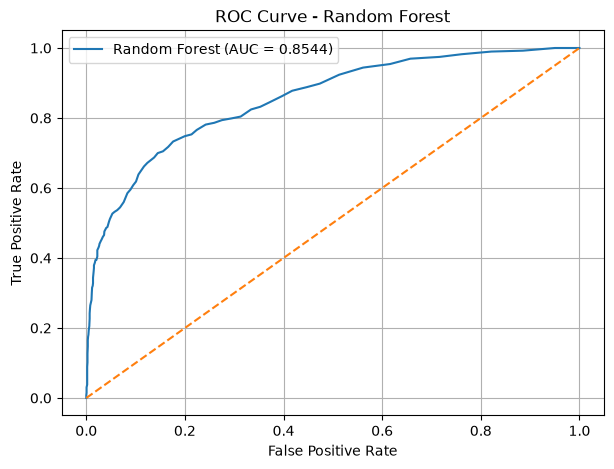

In [76]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability of the customer exiting
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

# Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

model_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

model_results

,Metric,Score
0,Accuracy,0.866000
1,Precision,0.759336
2,Recall,0.465649
3,F1-Score,0.577287
4,ROC-AUC,0.854406


In [78]:
print("FINAL BUSINESS INSIGHTS")
print("=======================")

print("1. Overall customer churn rate is 20.37%.")
print("2. Germany has the highest geographical churn rate at 32.44%, compared with 16.15% in France and 16.67% in Spain.")
print("3. Customers aged 51-60 have the highest observed churn rate at 56.21%.")
print("4. Inactive members have a higher churn rate (26.85%) than active members (14.27%).")
print("5. Customers with three products show a very high observed churn rate of 82.71%; however, this group is relatively small.")
print("6. High-balance customers show higher churn than low-balance customers.")
print("7. Age is the most important feature in the Random Forest model, with feature importance of approximately 0.238.")
print("8. The Random Forest model achieved 86% accuracy and a ROC-AUC of 0.8544.")
print("9. The model's recall for churners is approximately 46.55%, indicating that further improvement is possible in identifying customers likely to leave.")

FINAL BUSINESS INSIGHTS
1. Overall customer churn rate is 20.37%.
2. Germany has the highest geographical churn rate at 32.44%, compared with 16.15% in France and 16.67% in Spain.
3. Customers aged 51-60 have the highest observed churn rate at 56.21%.
4. Inactive members have a higher churn rate (26.85%) than active members (14.27%).
5. Customers with three products show a very high observed churn rate of 82.71%; however, this group is relatively small.
6. High-balance customers show higher churn than low-balance customers.
7. Age is the most important feature in the Random Forest model, with feature importance of approximately 0.238.
8. The Random Forest model achieved 86% accuracy and a ROC-AUC of 0.8544.
9. The model's recall for churners is approximately 46.55%, indicating that further improvement is possible in identifying customers likely to leave.


In [79]:
print("FINAL BUSINESS RECOMMENDATIONS")
print("=============================")

print("1. Launch targeted retention campaigns for customers aged 51-60, the highest-risk age group.")
print("2. Investigate the causes of high churn in Germany and design Germany-specific retention strategies.")
print("3. Re-engage inactive members through personalized communication, offers, and service follow-ups.")
print("4. Review customers with multiple products and investigate why customers with three products show unusually high churn.")
print("5. Provide proactive support to high-balance customers to reduce the risk of losing valuable customers.")
print("6. Use the churn prediction model to identify high-risk customers and prioritize retention efforts.")
print("7. Monitor model performance regularly and improve the model's ability to identify actual churners.")
print("8. Combine model predictions with customer-service and business information before taking retention actions.")

FINAL BUSINESS RECOMMENDATIONS
1. Launch targeted retention campaigns for customers aged 51-60, the highest-risk age group.
2. Investigate the causes of high churn in Germany and design Germany-specific retention strategies.
3. Re-engage inactive members through personalized communication, offers, and service follow-ups.
4. Review customers with multiple products and investigate why customers with three products show unusually high churn.
5. Provide proactive support to high-balance customers to reduce the risk of losing valuable customers.
6. Use the churn prediction model to identify high-risk customers and prioritize retention efforts.
7. Monitor model performance regularly and improve the model's ability to identify actual churners.
8. Combine model predictions with customer-service and business information before taking retention actions.


In [1]:
import pickle

# Save the fitted Random Forest model
with open("random_forest_churn_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Random Forest model saved successfully!")

NameError: name 'rf_model' is not defined

In [2]:
[name for name in globals() if "model" in name.lower()]

[]

In [18]:
y_pred = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8695


In [20]:
import pickle

with open("random_forest_churn_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [21]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!
